# Forum Diskusi 4 - Pengantar Data Science
## Pertemuan 4: Statistika Dasar & Analisis Data

Nama: Difa Asmana  
NIM: 240401010008

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Langkah 1 - Load dan Inspect Dataset
Pada bagian ini saya memuat dataset Iris dan menampilkan shape, tipe data, 5 baris pertama, serta ringkasan statistik awal.

In [10]:
df = sns.load_dataset('iris')

print('Shape:', df.shape)
print('\nTipe data:')
print(df.dtypes)
print('\n5 baris pertama:')
print(df.head())
print('\nDescribe:')
print(df.describe().round(3))

Shape: (150, 5)

Tipe data:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

5 baris pertama:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Describe:
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        1.300
75%  

## Langkah 2 - Statistik Deskriptif Lengkap
Pada bagian ini saya menghitung mean, median, standar deviasi, varians, skewness, dan kurtosis untuk setiap kolom numerik.

In [11]:
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'\n=== {col_name} ===')
    print(f' Mean     : {col.mean():.3f}')
    print(f' Median   : {col.median():.3f}')
    print(f' Std Dev  : {col.std():.3f}')
    print(f' Varians  : {col.var():.3f}')
    print(f' Skewness : {col.skew():.3f}')
    print(f' Kurtosis : {col.kurt():.3f}')


=== sepal_length ===
 Mean     : 5.843
 Median   : 5.800
 Std Dev  : 0.828
 Varians  : 0.686
 Skewness : 0.315
 Kurtosis : -0.552

=== sepal_width ===
 Mean     : 3.057
 Median   : 3.000
 Std Dev  : 0.436
 Varians  : 0.190
 Skewness : 0.319
 Kurtosis : 0.228

=== petal_length ===
 Mean     : 3.758
 Median   : 4.350
 Std Dev  : 1.765
 Varians  : 3.116
 Skewness : -0.275
 Kurtosis : -1.402

=== petal_width ===
 Mean     : 1.199
 Median   : 1.300
 Std Dev  : 0.762
 Varians  : 0.581
 Skewness : -0.103
 Kurtosis : -1.341


## Langkah 3 - Analisis Distribusi
Pada bagian ini saya membuat histogram dan KDE untuk variabel sepal_length, lalu menambahkan garis mean dan median untuk membantu melihat bentuk distribusinya.

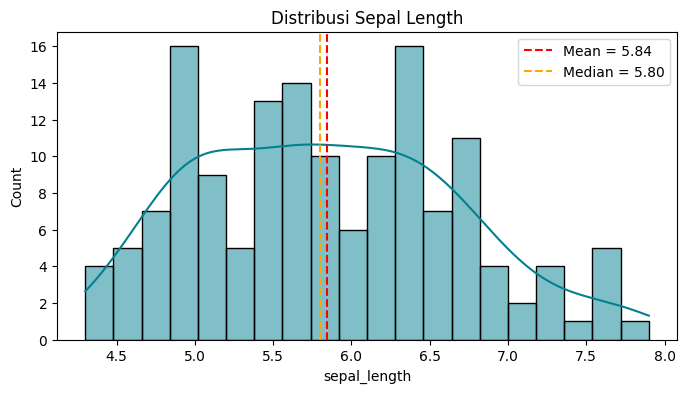

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['sepal_length'], kde=True, color='#028090', bins=20, ax=ax)

ax.axvline(df['sepal_length'].mean(), color='red', linestyle='--',
           label=f"Mean = {df['sepal_length'].mean():.2f}")
ax.axvline(df['sepal_length'].median(), color='orange', linestyle='--',
           label=f"Median = {df['sepal_length'].median():.2f}")

ax.set_title('Distribusi Sepal Length')
ax.legend()
plt.show()

### Interpretasi Distribusi
Grafik menunjukkan distribusi `sepal_length` pada dataset Iris. Garis mean dan median terlihat cukup berdekatan, sehingga distribusinya cenderung mendekati simetris. Untuk memastikan lebih lanjut, saya juga melihat nilai skewness pada langkah statistik deskriptif sebelumnya.

## Langkah 4 - Boxplot dan Violin Plot per Spesies
Pada bagian ini saya membandingkan distribusi `petal_length` antar spesies menggunakan boxplot dan violin plot.

/tmp/ipykernel_22919/78049374.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='petal_length', palette='Set2', ax=axes[0])
/tmp/ipykernel_22919/78049374.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y='petal_length', palette='Set2', inner='box', ax=axes[1])


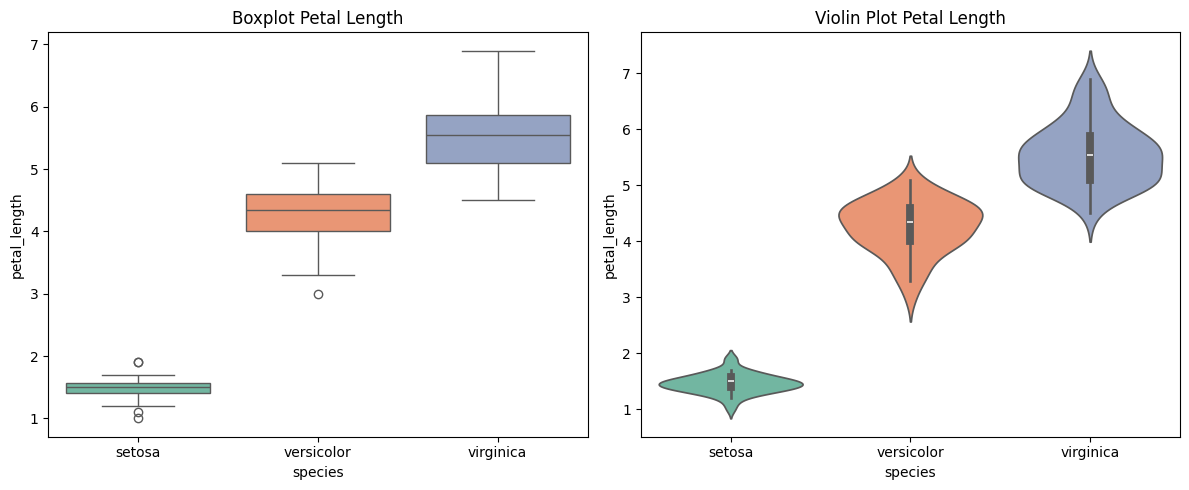

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='species', y='petal_length', palette='Set2', ax=axes[0])
axes[0].set_title('Boxplot Petal Length')

sns.violinplot(data=df, x='species', y='petal_length', palette='Set2', inner='box', ax=axes[1])
axes[1].set_title('Violin Plot Petal Length')

plt.tight_layout()
plt.show()

### Interpretasi Boxplot / Violin
Dari grafik terlihat bahwa `setosa` memiliki `petal_length` paling kecil, `virginica` paling besar, dan `versicolor` berada di tengah. Sebaran `virginica` juga terlihat lebih tinggi dibanding `setosa`, sehingga variasi datanya lebih besar. Grafik ini membantu membedakan karakteristik tiap spesies secara visual.

## Langkah 5 - Matriks Korelasi Pearson
Pada bagian ini saya menghitung korelasi Pearson antar kolom numerik dan mencari pasangan dengan korelasi tertinggi.

In [14]:
corr = df.drop('species', axis=1).corr(method='pearson')
print(corr.round(3))

mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)

max_pair = corr_masked.stack().idxmax()
min_pair = corr_masked.stack().idxmin()

print(f"\nKorelasi tertinggi : {max_pair} = {corr.loc[max_pair]:.3f}")
print(f"Korelasi terendah  : {min_pair} = {corr.loc[min_pair]:.3f}")

              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000

Korelasi tertinggi : ('petal_width', 'petal_length') = 0.963
Korelasi terendah  : ('petal_length', 'sepal_width') = -0.428


### Interpretasi Korelasi
Dari matriks korelasi, pasangan dengan hubungan paling kuat dapat diidentifikasi dari nilai korelasi terbesar. Nilai mendekati 1 menunjukkan hubungan positif kuat, sedangkan nilai mendekati -1 menunjukkan hubungan negatif kuat. Namun, korelasi tidak berarti kausalitas, sehingga hubungan ini tidak otomatis menunjukkan sebab-akibat.

## Langkah 6 - Scatter Plot dan Heatmap
Pada bagian ini saya membuat scatter plot untuk pasangan variabel yang sangat berkorelasi dan heatmap korelasi lengkap.

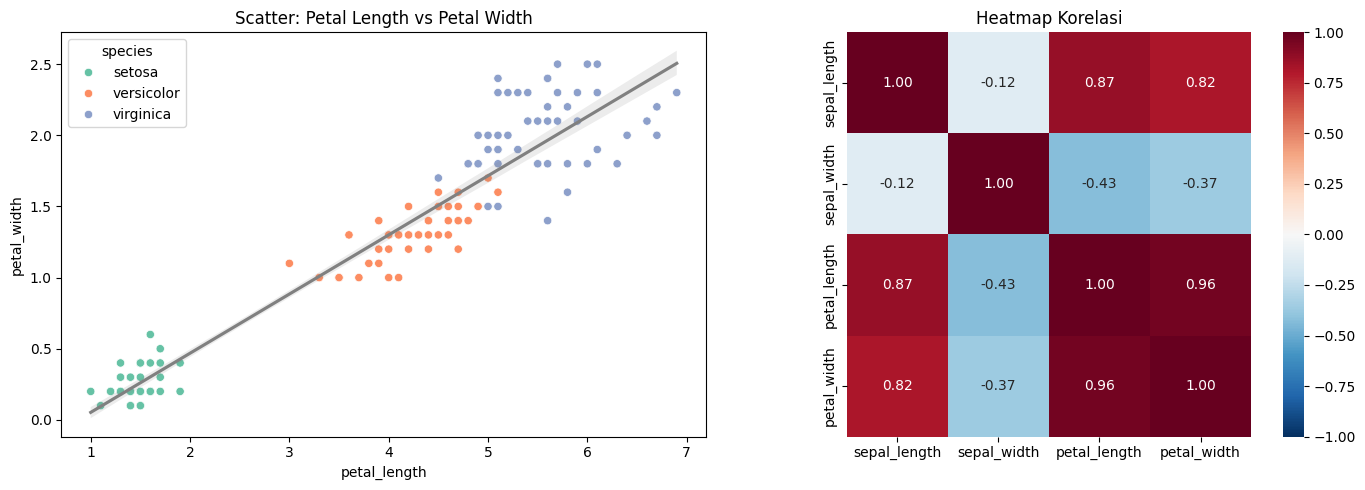

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='petal_length', y='petal_width',
                hue='species', palette='Set2', ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width',
            scatter=False, color='gray', ax=axes[0])
axes[0].set_title('Scatter: Petal Length vs Petal Width')

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Heatmap Korelasi')

plt.tight_layout()
plt.show()

### Interpretasi Scatter Plot dan Heatmap
Scatter plot menunjukkan bahwa `petal_length` dan `petal_width` memiliki hubungan positif yang sangat kuat: semakin panjang petal, umumnya semakin lebar petalnya. Heatmap memperjelas hubungan antar semua variabel numerik sekaligus, sehingga lebih mudah melihat pasangan yang korelasinya kuat, lemah, maupun negatif. Visualisasi ini membantu memahami pola hubungan antar fitur pada dataset Iris.

## Kesimpulan
Pada praktikum ini saya melakukan eksplorasi statistik dasar terhadap dataset Iris menggunakan ukuran pemusatan, ukuran penyebaran, distribusi data, boxplot, violin plot, korelasi, scatter plot, dan heatmap. Dari hasil visualisasi dan statistik, terlihat bahwa beberapa variabel bunga Iris memiliki hubungan yang kuat dan dapat dibedakan dengan cukup jelas antar spesies.